In [ ]:
from pathlib import Path
from datetime import datetime

from matplotlib import pyplot as plt
import numpy as np
import pydicom
from scipy import ndimage

from pylinac.core.image_generator import AS1200Image, AS1000Image
import pylinac.core.image_generator.layers as layers

from metrics import run_analysis_on_path

In [13]:
def generate_dicom_using_layers(file_out_name, layers):
    as1200 = AS1200Image(sid=1000)
    for layer in layers:
        as1200.add_layer(layer)
    as1200.generate_dicom(file_out_name=file_out_name, gantry_angle=0)
    plt.imsave(file_out_name.with_suffix('.png'), as1200.image)
    return as1200

dir_path = Path(".")
dir_path = dir_path / "test_images"
dir_path.mkdir(parents=True, exist_ok=True)

In [8]:
class FilteredFieldLayer2(layers.PerfectFieldLayer):
    """A square field with flattening filter effects"""

    def __init__(
        self,
        field_size_mm: tuple[float, float] = (10, 10),
        cax_offset_mm: tuple[float, float] = (0, 0),
        alpha: float = 1.0,
        gaussian_height: float = 0.03,
        gaussian_sigma_mm: float = 32,
        horn_center_offset_mm: tuple[float, float] = (0, 0),
        rotation: float = 0,
    ):
        
        super().__init__(
            field_size_mm=field_size_mm,
            cax_offset_mm=cax_offset_mm,
            alpha=alpha,
            rotation=rotation,
        )
        self.gaussian_height = gaussian_height
        self.gaussian_sigma_mm = gaussian_sigma_mm
        self.horn_center_offset_mm = horn_center_offset_mm
    
    def apply(self, image: np.array, pixel_size: float, mag_factor: float) -> np.array:
        image, rr, cc = self._create_perfect_field(image, pixel_size, mag_factor)
        # add filter effect
        height = -self.gaussian_height * np.iinfo(image.dtype).max
        width = self.gaussian_sigma_mm / pixel_size
        center_x = self.horn_center_offset_mm[0] / pixel_size + layers.geometric_center_idx(image[:, 0])
        center_y = self.horn_center_offset_mm[1] / pixel_size + layers.geometric_center_idx(image[0, :])
        # center_x = layers.geometric_center_idx(image[:, 0])
        # center_y = layers.geometric_center_idx(image[0, :])
        horns = layers.gaussian2d(
            rr,
            cc,
            height=height,
            center_x=center_x,
            center_y=center_y,
            width_x=width,
            width_y=width,
        )
        # the horns are negative, so we don't have
        # to worry about clipping here
        image[rr, cc] += horns.astype(image.dtype)
        return image

In [ ]:
as1200 = AS1200Image()
as1200.add_layer(FilteredFieldLayer2(
    field_size_mm=(120, 100),
    cax_offset_mm=(0, 0),
    alpha=1.0,
    gaussian_height=0.3,
    gaussian_sigma_mm=15,
    horn_center_offset_mm=(40, 30),
))

as1200.add_layer(layers.GaussianFilterLayer())

as1200.generate_dicom(file_out_name="artifact_test.dcm", gantry_angle=0)
plt.imshow(as1200.image)

58762


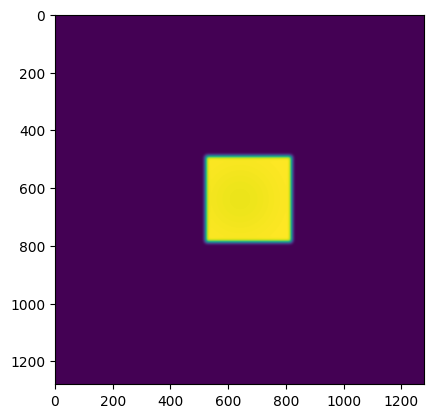

In [14]:
field_layers = [
layers.FilteredFieldLayer(
    field_size_mm=(100, 100),
    alpha=0.9,
    cax_offset_mm=(0, 10)
),
layers.GaussianFilterLayer()
]
file_path = dir_path / "cax_offset_10_mm_10x10.dcm"
simulator_instance = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(simulator_instance.image)
print(simulator_instance.image.max())

64436


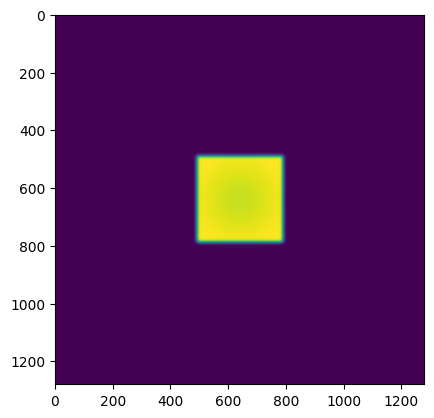

In [11]:
field_layers = [
    layers.FilteredFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.1, 
    gaussian_sigma_mm=32.0,
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_excess_horns_10x10.dcm"
as1200 = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(as1200.image)
print(as1200.image.max())

In [ ]:
field_layers = [
    layers.FilteredFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.1, 
    gaussian_sigma_mm=32.0,
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_excess_horns_10x10.dcm"
as1200 = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(as1200.image)
print(as1200.image.max())

pylinac_version: 3.44.0
date_of_analysis: 2026-06-18T10:10:50.192499
warnings: []
x_metrics:
Field Size Calculation by FWHM (mm): 110.54400000000001
Flatness Calculation by Variance (%): 4.132004810598271
Flatness Calculation by Ratio (IEC) (%): 107.99360407675108
Flatness Calculation by CAX Variance: 0.5804509717429098
Flatness Calculation by CAX Ratio: 1.0919328472456473
Symmetry Calculation by CAX Point Difference (%): -2.7997612807805083
Symmetry Calculation by Point Ratio (IEC 976) (%): 107.88280976065867
Symmetry Calculation by Area (%): 5.208375027108155
Field Width (mm): 110.0133760246838
y_metrics:
Field Size Calculation by FWHM (mm): 100.12800000000001
Flatness Calculation by Variance (%): 2.4640147046038825
Flatness Calculation by Ratio (IEC) (%): 103.55382950276946
Flatness Calculation by CAX Variance: 0.5136031092821216
Flatness Calculation by CAX Ratio: 1.052659655540314
Symmetry Calculation by CAX Point Difference (%): -4.035208047553727
Symmetry Calculation by Point Rat

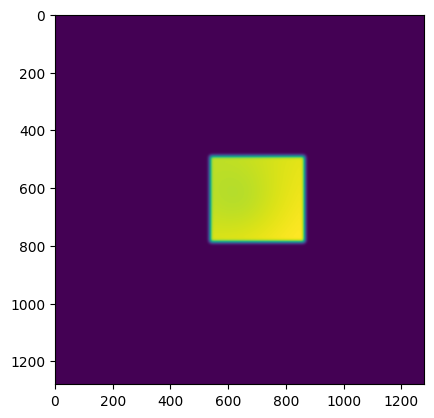

In [35]:
file_path = dir_path / "symmetry_two_percent_x_and_y_area_10x10.dcm"
field_layers = [
layers.FilteredFieldLayer(
    field_size_mm=(100, 110),
    cax_offset_mm=(0, 20),
    alpha=0.5,
),
layers.SlopeLayer(
    slope_x=0.2371,
    slope_y=0.2371
),
layers.GaussianFilterLayer()
]
simulator_instance = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(simulator_instance.image)
print(run_analysis_on_path(file_path))

In [ ]:
field_layers = [
    layers.FilterFreeFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_imperfect_fff_10x10.dcm"
as1200 = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(as1200)